#### Imports

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
import torch

from iwp.algorithms.algorithms import (
    FISTA,
    ForwardBackward,
    GradientDescent,
    NesterovAcceleratedGradientDescent,
    StronglyConvexNesterovAcceleratedGradientDescent,
    DistributedBlockGradientDescent,
)
from iwp.algorithms.plot import plot_all_algorithms_convergence, plot_objective_functions_by_algorithm
from iwp.algorithms.metrics import mae, mse
from iwp.data.load_experiment_data import load_experiment_data
from iwp.data.export import save_complex_vector
from iwp.utils.config import load_yaml_into_namespace
from iwp.utils.logger import setup_logger
from iwp.utils.utils import copy_file, make_dirs, set_seed

In [3]:
from types import SimpleNamespace
args = SimpleNamespace(
    config = os.path.join(os.getcwd(), "src/iwp/config.yaml"),
)
args = load_yaml_into_namespace(args.config, args)

logger = setup_logger(
    name="iwp",
    log_file=None,
    level=args.log_level,
    log_to_console=args.log_to_console,
)

# Setup device and seed
if args.device == "cuda" and not torch.cuda.is_available():
    logger.warning("CUDA is not available. Falling back to CPU.")
    args.device = "cpu"
if args.device not in ["cpu", "cuda"]:
    raise ValueError("Device must be either 'cpu' or 'cuda'.")
logger.info(f"Using device: {args.device}")
set_seed(args.seed)

# Load data
A, B_list, C, d_list, m = load_experiment_data(args.data_path)
A_star = A.conj().T
C_star = C.conj().T

I = len(B_list)
J, L = C.shape
P = B_list[0].shape[1]
logger.info(f"Dimensions: I={I}, J={J}, L={L}, P={P}")

row_blocks = []
for i in range(I):
    blocks = [sp.csr_matrix((J, L))] * I + [sp.csr_matrix((J, P))]
    blocks[i] = sp.csr_matrix(C)
    row_blocks.append(sp.hstack(blocks, format="csr"))
D = sp.vstack(
    row_blocks, format="csr"
)  # shape: (I*J, I*L + P) if A is (L,L), B_i is (L,P)
D_star = D.conj().T

d = np.concatenate(d_list, axis=0)  # shape: (I*J,)

row_blocks = []
for i in range(I):
    blocks = [sp.csr_matrix((L, L))] * I + [-B_list[i]]
    blocks[i] = sp.csr_matrix(A)
    row_blocks.append(sp.hstack(blocks, format="csr"))
E = sp.vstack(row_blocks, format="csr")  # shape: (I*L, I*L + P)
E_star = E.conj().T

def get_J_1(d, lambd, mu):
    def J_1(x):
        Dx_minus_d = D @ x - d
        Ex = E @ x
        return (
            0.5 * np.vdot(Dx_minus_d, Dx_minus_d).real
            + 0.5 * lambd * np.vdot(Ex, Ex).real
            + 0.5 * mu * np.vdot(x, x).real
        )

    return J_1

def get_dJ_1(d, lambd, mu):
    def dJ_1(x):
        Dx_minus_d = D @ x - d
        Ex = E @ x
        return D.conj().T @ Dx_minus_d + lambd * E_star @ Ex + mu * x

    return dJ_1

def get_closed_form_solution_J_1(d, lambd, mu):
    def closed_form_solution_J_1():
        return sp.linalg.spsolve(
            D.conj().T @ D + lambd * E_star @ E + mu * sp.eye(I * L + P),
            D.conj().T @ d,
        )

    return closed_form_solution_J_1

def get_K_J_1(lambd, mu):
    K_op_J_1 = D.conj().T @ D + lambd * E_star @ E + mu * sp.eye(I * L + P)
    K_eigenvalues_J_1 = np.linalg.eigvals(K_op_J_1.toarray())
    return np.max(np.abs(K_eigenvalues_J_1))

def get_J_2(d, mu, threshold=1e-6):
    def J_2(x):
        Dx_minus_d = D @ x - d
        Ex = E @ x
        if np.linalg.norm(Ex) < threshold:
            return (
                0.5 * np.vdot(Dx_minus_d, Dx_minus_d).real
                + 0.5 * mu * np.vdot(x[-P:], x[-P:]).real
            )
        else:
            return np.inf

    return J_2

def get_grad_J_2(d, mu):
    def grad_J_2(x):
        reg = np.zeros_like(x)
        reg[-P:] = mu * x[-P:]
        return D_star @ (D @ x - d) + reg

    return grad_J_2

def get_prox_J_2():
    def prox_J_2(x, gamma):
        w = sp.linalg.spsolve(E @ E_star, E @ x)
        return x - E_star @ w

    return prox_J_2

def get_K_J_2(mu):
    K_op_J_2 = D.conj().T @ D + mu * sp.eye(I * L + P)
    K_eigenvalues_J_2 = np.linalg.eigvals(K_op_J_2.toarray())
    return np.max(np.abs(K_eigenvalues_J_2))

def get_J_3(d_list, mu):
    def J_3(m):
        total = 0.0
        for i in range(len(B_list)):
            CA_inv_Bi_m = C @ sp.linalg.spsolve(A, B_list[i] @ m)
            diff = CA_inv_Bi_m - d_list[i]
            total += 0.5 * np.vdot(diff, diff).real
        return total + 0.5 * mu * np.vdot(m, m).real

    return J_3

def get_dJ_3(d_list, mu):
    def dJ_3(m):
        p_sum = sum(
            B_i.conj().T
            @ sp.linalg.spsolve(
                A_star,
                C_star @ (C @ sp.linalg.spsolve(A, B_i @ m) - d_i),
            )
            for B_i, d_i in zip(B_list, d_list)
        )
        return p_sum + mu * m

    return dJ_3

def get_K_J_3(mu):
    Ainv = sp.linalg.inv(A.tocsc())
    K_op_J_3 = sum(
        B_i.conj().T @ Ainv.conj().T @ C.conj().T @ C @ Ainv @ B_i for B_i in B_list
    ) + mu * sp.eye(P)
    K_eigenvalues_J_3 = np.linalg.eigvals(K_op_J_3.toarray())
    return np.max(np.abs(K_eigenvalues_J_3)) 

# Distributed Gradient Descent helpers (gradients for u and m and Lipschitz estimates)
def get_grad_u(d_list, rho):
    def grad_u(i, u_i, m):
        return C_star @ (C @ u_i - d_list[i]) + rho * (A_star @ (A @ u_i - B_list[i] @ m))
    return grad_u

def get_grad_m(agent_indices, dg, rho, S):
    def grad_m(s, m, u_list):
        grad_sum = np.zeros_like(m)
        for i in agent_indices[s]:
            grad_sum += B_list[i].conj().T @ (B_list[i] @ m - A @ u_list[i])
        return rho * grad_sum + (1.0 / S) * dg(m)
    return grad_m

def dg_tikhonov(mu=1.0):
    return lambda m: mu * m

def get_K_DBGD(rho, mu, S):
    # Lipschitz for u-block gradients: ||C^H C + rho A^H A||_2
    K_op_u = C_star @ C + rho * (A_star @ A)
    K_eig_u = np.linalg.eigvals(K_op_u.toarray() if sp.issparse(K_op_u) else K_op_u)
    K_u = np.max(np.abs(K_eig_u))

    # Lipschitz for m-gradient: rho * ||sum_i B_i^H B_i||_2 + (1/S)*mu
    sum_BTB = sum(B_i.conj().T @ B_i for B_i in B_list)
    sum_BTB_mat = sum_BTB.toarray() if sp.issparse(sum_BTB) else sum_BTB
    K_sum_BTB = np.max(np.abs(np.linalg.eigvals(sum_BTB_mat)))
    K_m = rho * K_sum_BTB + (1.0 / S) * mu

    return max(K_u, K_m)

2026-06-01 14:00:51 - iwp - INFO - Using device: cpu


2026-06-01 14:00:51 - iwp - INFO - Set seed for all random number generators to seed 42
2026-06-01 14:00:51 - iwp - INFO - Found 2 B matrices.
2026-06-01 14:00:51 - iwp - INFO - Loaded data.
2026-06-01 14:00:51 - iwp - INFO - Dimensions: I=2, J=50, L=223, P=394


In [12]:
lambd = 1e-4
rho = 1e-1
mu_1 = 1e-6
mu_2 = 1e-6
mu_3 = 1e-6

max_iterations = 10000
x_0 = np.zeros(I * L + P, dtype=np.complex128)  # shape: (I*L + P,)

J_1 = get_J_1(d, lambd, mu_1)
dJ_1 = get_dJ_1(d, lambd, mu_1)
closed_form_solution_J_1 = get_closed_form_solution_J_1(d, lambd, mu_1)
K_J_1 = get_K_J_1(lambd, mu_1)
logger.info(f"Lipschitz constant K_J_1: {K_J_1}")

J_2 = get_J_2(d, mu_2)
grad_J_2 = get_grad_J_2(d, mu_2)
prox_J_2 = get_prox_J_2()
K_J_2 = get_K_J_2(mu_2)
logger.info(f"Lipschitz constant K_J_2: {K_J_2}")

J_3 = get_J_3(d_list, mu_3)
dJ_3 = get_dJ_3(d_list, mu_3)
K_J_3 = get_K_J_3(mu_3)
logger.info(f"Lipschitz constant K_J_3: {K_J_3}")

# Distributed Block Gradient Descent (DBGD) setup and run
S = 2
agent_indices = [[i for i in range(s, I, S)] for s in range(S)]
W = np.full((S, S), 1.0 / S)

dg = dg_tikhonov(mu=mu_1)
grad_u = get_grad_u(d_list, rho)
grad_m = get_grad_m(agent_indices, dg, rho, S)
J_1 = get_J_1(d, lambd, mu_1)
K_DBGD = get_K_DBGD(rho, mu_1, S)
logger.info(f"Lipschitz constant K_DBGD: {K_DBGD}")

2026-06-01 14:49:36 - iwp - INFO - Lipschitz constant K_J_1: 5.09099941916731
2026-06-01 14:49:38 - iwp - INFO - Lipschitz constant K_J_2: 5.0891978715766575
2026-06-01 14:49:38 - iwp - INFO - Lipschitz constant K_J_3: 0.5827462612350574
2026-06-01 14:49:39 - iwp - INFO - Lipschitz constant K_DBGD: 7.1657611505518535


In [13]:
algo_5 = FISTA(
    exp_name=args.exp_name,
    algo_plot_name="FISTA",
    f=J_2,
    grad=grad_J_2,
    prox=prox_J_2,
    K=K_J_2,
    logger=logger,
)
algo_5.run(x0=x_0, max_iterations=max_iterations)
algo_5.plot_algorithm_convergence(m, None, show=False, save=False)

algo_6 = GradientDescent(
    exp_name=args.exp_name,
    algo_plot_name="C-GD",
    f=J_3,
    df=dJ_3,
    K=K_J_3,
    gamma=2.0 / K_J_3 - 8e-1,
    logger=logger,
)
algo_6.run(x0=x_0[-P:], max_iterations=max_iterations)
algo_6.plot_algorithm_convergence(m, None, show=False, save=False)

algo_7 = NesterovAcceleratedGradientDescent(
    exp_name=args.exp_name,
    algo_plot_name="C-NAGD",
    f=J_3,
    df=dJ_3,
    K=K_J_3,
    logger=logger,
)
algo_7.run(x0=x_0[-P:], max_iterations=max_iterations)
algo_7.plot_algorithm_convergence(m, None, show=False, save=False)



alpha = 0.9 / K_DBGD if K_DBGD > 0 else 1e-3

algo_dbgd = DistributedBlockGradientDescent(
    exp_name=args.exp_name,
    algo_plot_name="D-BGD",
    f=lambda x: J_1(x),
    grad_u=grad_u,
    grad_m=grad_m,
    S=S,
    W=W,
    alpha=alpha,
    P=P,
    L=L,
    I=I,
    agent_indices=agent_indices,
    use_mpi=True,
    logger=logger,
)
x_dbgd = algo_dbgd.run(x0=x_0, max_iterations=max_iterations)
algo_dbgd.plot_algorithm_convergence(m, None, show=False, save=False)



2026-06-01 14:49:39 - iwp - INFO - Started FISTA for a maximum of 10000 iterations.
2026-06-01 14:52:56 - iwp - INFO - Stopped after 10000 iterations in 197.607 seconds with 439.51 KB memory used.
2026-06-01 14:52:59 - iwp - INFO - Started C-GD for a maximum of 10000 iterations.
2026-06-01 14:55:29 - iwp - INFO - Stopped after 10000 iterations in 150.273 seconds with 101.67 KB memory used.
2026-06-01 14:55:31 - iwp - INFO - Started C-NAGD for a maximum of 10000 iterations.
2026-06-01 14:56:05 - iwp - INFO - Converged after 2150 iterations in 34.309 seconds with 115.32 KB memory used.
2026-06-01 14:56:18 - iwp - INFO - Started D-BGD for a maximum of 10000 iterations.
2026-06-01 14:56:55 - iwp - INFO - Stopped after 10000 iterations in 36.950 seconds with 233.23 KB memory used.


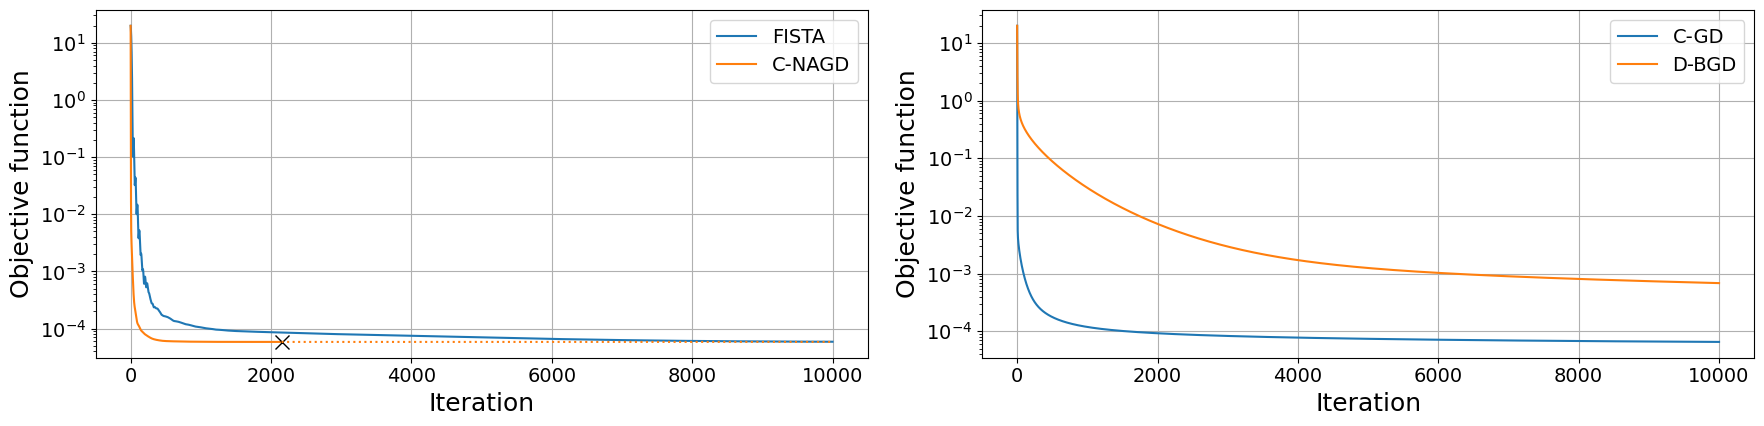

In [14]:
plot_objective_functions_by_algorithm(
    [
        [algo_5, algo_7],
        [ algo_6,algo_dbgd]
        
    ],
    visuals_path=None,
    show=True,
    save=False,
    )

#### Hyperparameters

In [5]:
mus = np.array([1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1])
rhos = np.array([1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e0])

2026-06-01 14:42:27 - iwp - INFO - Started μ=1e-08 for a maximum of 5000 iterations.
2026-06-01 14:42:40 - iwp - INFO - Stopped after 5000 iterations in 12.993 seconds with 69891.83 KB memory used.
2026-06-01 14:42:41 - iwp - INFO - Started μ=1e-07 for a maximum of 5000 iterations.
2026-06-01 14:42:59 - iwp - INFO - Stopped after 5000 iterations in 17.391 seconds with 133.53 KB memory used.
2026-06-01 14:43:00 - iwp - INFO - Started μ=1e-06 for a maximum of 5000 iterations.
2026-06-01 14:43:25 - iwp - INFO - Stopped after 5000 iterations in 24.185 seconds with 152.96 KB memory used.
2026-06-01 14:43:26 - iwp - INFO - Started μ=1e-05 for a maximum of 5000 iterations.
2026-06-01 14:43:42 - iwp - INFO - Stopped after 5000 iterations in 16.174 seconds with 157.94 KB memory used.
2026-06-01 14:43:44 - iwp - INFO - Started μ=1e-04 for a maximum of 5000 iterations.
2026-06-01 14:43:59 - iwp - INFO - Stopped after 5000 iterations in 15.546 seconds with 155.06 KB memory used.
2026-06-01 14:44:0

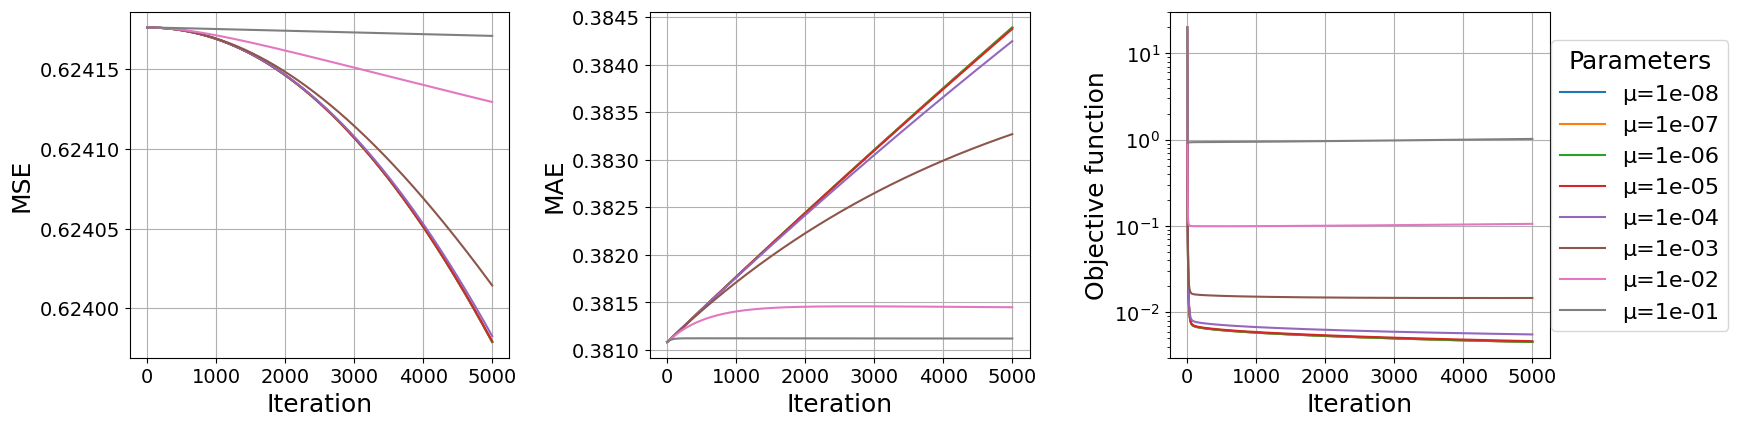

In [10]:
max_iter =5000

algo_list = []
x_list = []
for mu_val in mus:
    dg = dg_tikhonov(mu=mu_val)
    grad_u = get_grad_u(d_list, rho)
    grad_m = get_grad_m(agent_indices, dg, rho, S)
    J_1 = get_J_1(d, lambd, mu_val)
    K_DBGD = get_K_DBGD(rho, mu_val, S)
    alpha = 0.9 / K_DBGD
    algo_dbgd = DistributedBlockGradientDescent(
        exp_name=args.exp_name,
        algo_plot_name=f"μ={mu_val:.0e}",
        f=lambda x: J_1(x),
        grad_u=grad_u,
        grad_m=grad_m,
        S=S,
        W=W,
        alpha=alpha,
        P=P,
        L=L,
        I=I,
        agent_indices=agent_indices,
        use_mpi=True,
        logger=logger,
    )
    x_dbgd = algo_dbgd.run(x0=x_0, max_iterations=max_iter)
    algo_dbgd.plot_algorithm_convergence(m, None, show=False, save=False)
    algo_list.append(algo_dbgd)
    x_list.append(x_dbgd)

plot_all_algorithms_convergence(
    algorithms=algo_list,
    visuals_path=None,
    show=True,
    save=False,
    show_time_memory=False,
)

2026-06-01 14:45:51 - iwp - INFO - Started rho=1e-06 for a maximum of 5000 iterations.
2026-06-01 14:46:15 - iwp - INFO - Stopped after 5000 iterations in 24.133 seconds with 185.81 KB memory used.
2026-06-01 14:46:52 - iwp - INFO - Started rho=1e-05 for a maximum of 5000 iterations.
2026-06-01 14:47:08 - iwp - INFO - Stopped after 5000 iterations in 15.635 seconds with 233.59 KB memory used.
2026-06-01 14:47:09 - iwp - INFO - Started rho=1e-04 for a maximum of 5000 iterations.
2026-06-01 14:47:24 - iwp - INFO - Stopped after 5000 iterations in 15.160 seconds with 158.15 KB memory used.
2026-06-01 14:47:25 - iwp - INFO - Started rho=1e-03 for a maximum of 5000 iterations.
2026-06-01 14:47:40 - iwp - INFO - Stopped after 5000 iterations in 15.018 seconds with 155.89 KB memory used.
2026-06-01 14:47:44 - iwp - INFO - Started rho=1e-02 for a maximum of 5000 iterations.
2026-06-01 14:47:58 - iwp - INFO - Stopped after 5000 iterations in 13.382 seconds with 152.96 KB memory used.
2026-06-01

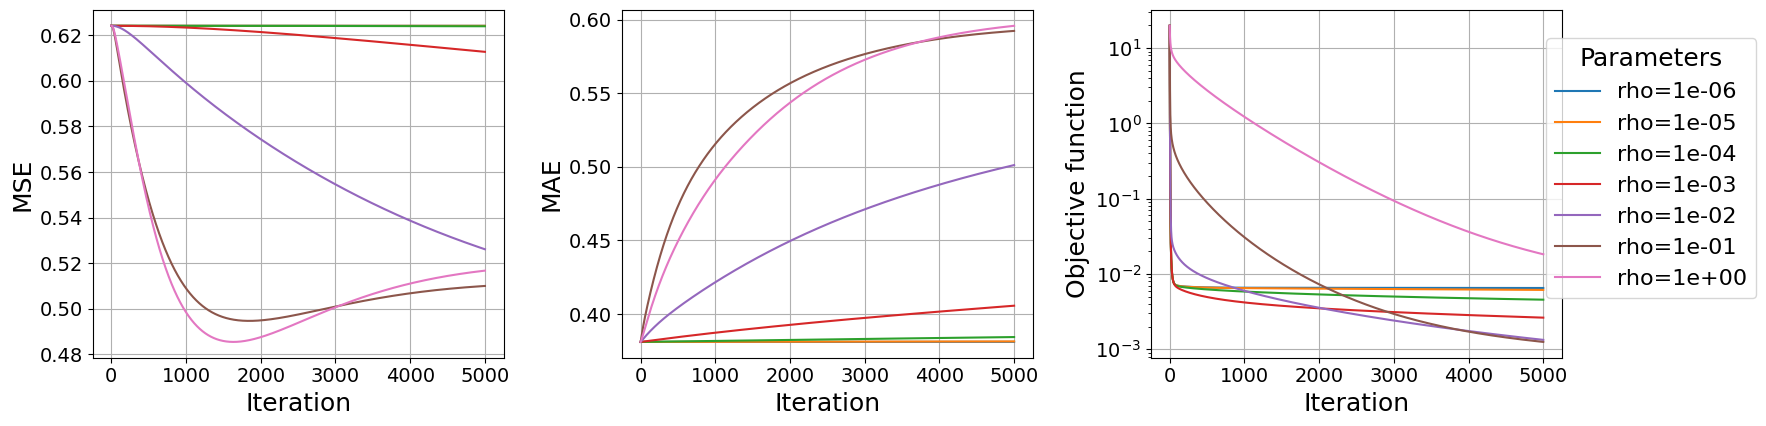

In [11]:
algo_list = []
x_list = []
for rho_val in rhos:
    dg = dg_tikhonov(mu=mu_1)
    grad_u = get_grad_u(d_list, rho_val)
    grad_m = get_grad_m(agent_indices, dg, rho_val, S)
    J_1 = get_J_1(d, lambd, mu_1)
    K_DBGD = get_K_DBGD(rho_val, mu_1, S)
    alpha = 0.9 / K_DBGD
    algo_dbgd = DistributedBlockGradientDescent(
        exp_name=args.exp_name,
        algo_plot_name=f"rho={rho_val:.0e}",
        f=lambda x: J_1(x),
        grad_u=grad_u,
        grad_m=grad_m,
        S=S,
        W=W,
        alpha=alpha,
        P=P,
        L=L,
        I=I,
        agent_indices=agent_indices,
        use_mpi=True,
        logger=logger,
    )
    x_dbgd = algo_dbgd.run(x0=x_0, max_iterations=max_iter)
    algo_dbgd.plot_algorithm_convergence(m, None, show=False, save=False)
    algo_list.append(algo_dbgd)
    x_list.append(x_dbgd)

plot_all_algorithms_convergence(
    algorithms=algo_list,
    visuals_path=None,
    show=True,
    save=False,
    show_time_memory=False,
)